In [5]:
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt

In [ ]:
img = np.ones((480, 640, 3), dtype=np.uint8) * 255

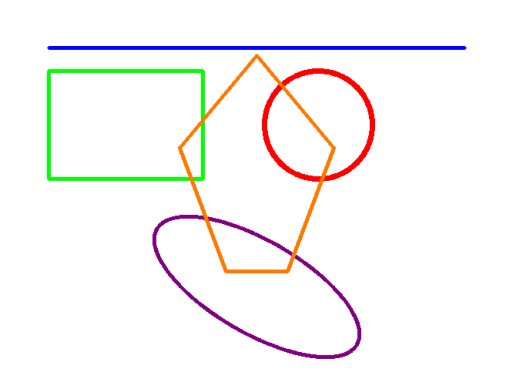

In [ ]:
cv.line(img, (50,50), (590, 50), (255, 0, 0), 3)
cv.rectangle(img, (50,80), (250,220), (0,255,0), 3)
cv.circle(img, (400,150), 70, (0,0,255), 5)
cv.ellipse(img, (320,360), (150,60), 30, 0, 360, (128,0,128), 4)
pts = np.array([[320,60],[420,180],[360,340],[280,340],[220,180]], np.int32)
cv.polylines(img, [pts], True, (0,120,255), 4)


plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

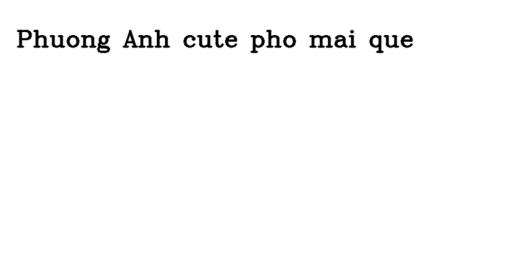

In [ ]:
# chèn text vào ảnh
image = np.ones((400, 800, 3), dtype=np.uint8) * 255
cv.putText(image, 'Phuong Anh cute pho mai que', (10, 60), cv.FONT_HERSHEY_COMPLEX, 1.2, (0,0,0), 2, cv.LINE_AA)
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2BGRA))
plt.axis('off')
plt.show()

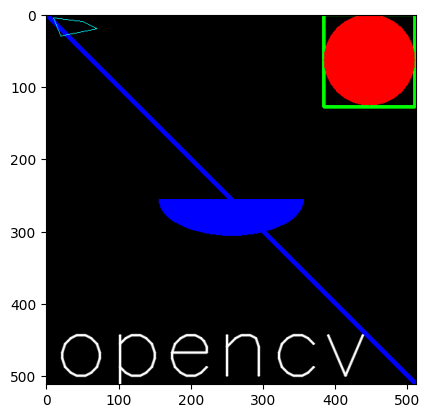

In [ ]:
img = np.zeros((512, 512, 3), dtype=np.uint8)
cv.line(img, (0,0), (511, 511), (0, 0, 255), 5)
cv.rectangle(img, (384, 0), (510, 128), (0, 255, 0),3)
cv.circle(img, (447, 63), 63, (255, 0, 0), -1)
cv.ellipse(img, (256, 256), (100, 50), 0, 0, 180, (0, 0, 255), -1)
pts = np.array([[10,5], [20,30], [70, 20], [50,10]], np.int32)
cv.polylines(img, [pts], True, (0, 255, 255))
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(img,  "opencv", (10, 500), font, 4, (255, 255, 255), 2, cv.LINE_AA)

plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2BGRA))
plt.show()

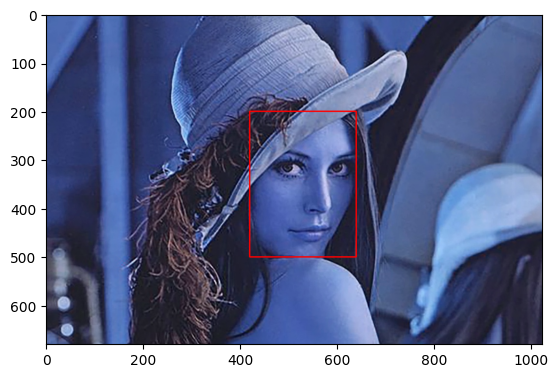

In [ ]:
# 9. Xác định khuôn mặt bằng hình chữ nhật
img = cv.imread('/content/img_lenna.jpg')
cv.rectangle(img, (420, 200), (640, 500), (255, 0, 0), 2)
plt.imshow(img)
plt.show()

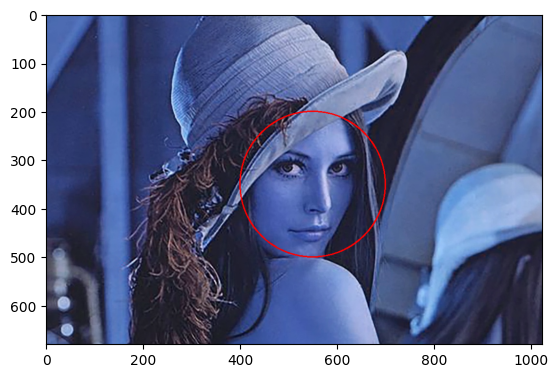

In [ ]:
# 10. Xác định khuôn mặt bằng khung hình tròn
image = cv.imread('/content/img_lenna.jpg')
cv.circle(image, (550, 350), 150, (255, 0, 0), 2)
plt.imshow(image)
plt.show()

In [1]:
import pywt
import math
import numpy as np

def wavelet_denoise(img_gray, wavelet='db1', level=2, threshold_scale=0.04):
    arr = img_gray.astype(np.float32)
    coeffs = pywt.wavedec2(arr, wavelet=wavelet, level=level)
    cH, cV, cD = coeffs[-1]
    detail = np.concatenate([cH.ravel(), cV.ravel(), cD.ravel()])
    sigma = np.median(np.abs(detail)) / 0.6745 + 1e-12
    uthresh = threshold_scale * sigma * np.sqrt(2 * np.log(arr.size))

    new_coeffs = [coeffs[0]]
    for detail in coeffs[1:]:
        cH, cV, cD = detail
        cH_t = pywt.threshold(cH, uthresh, mode='soft')
        cV_t = pywt.threshold(cV, uthresh, mode='soft')
        cD_t = pywt.threshold(cD, uthresh, mode='soft')
        new_coeffs.append((cH_t, cV_t, cD_t))

    reco = pywt.waverec2(new_coeffs, wavelet=wavelet)
    reco = np.clip(reco, 0, 255).astype(np.uint8)
    return reco

def mse_psnr(original, denoised):
    orig = original.astype(np.float64)
    den = denoised.astype(np.float64)
    mse = np.mean((orig - den) ** 2)
    psnr = float('inf') if mse == 0 else 10 * math.log10(255**2 / mse)
    return mse, psnr

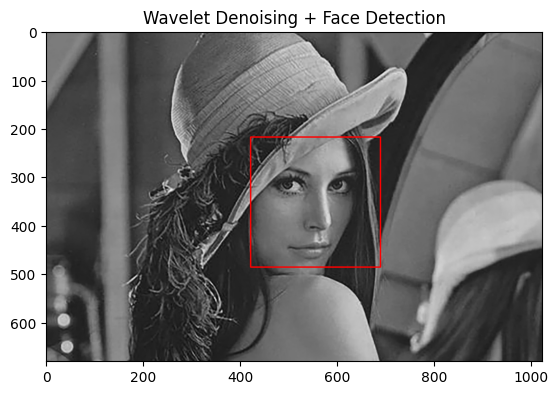

In [6]:
# 11.Tiến hành khử nhiễu ảnh bằng phép biến đổi Wavelet và nhận dạng khuôn mặt bằng khung hình chữ nhật trên ảnh đã khử nhiễu.
img = cv.imread('/content/img_lenna.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

denoised = wavelet_denoise(gray, wavelet='db1', level=2, threshold_scale=0.04)

# Phát hiện khuôn mặt bằng Haar Cascade
face_cascade = cv.CascadeClassifier(cv.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(denoised, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))

# Vẽ khung hình chữ nhật quanh khuôn mặt
den_bgr = cv.cvtColor(denoised, cv.COLOR_GRAY2BGR)
for (x, y, w, h) in faces:
    cv.rectangle(den_bgr, (x, y), (x+w, y+h), (0, 0, 255), 2)
plt.imshow(cv.cvtColor(den_bgr, cv.COLOR_BGR2RGB))
plt.title("Wavelet Denoising + Face Detection")
plt.show()

In [11]:
# 12. Tách frame từ video và lưu vào Google Drive

from google.colab import drive
import cv2 as cv
import os

drive.mount('/content/drive')

video_path = '/content/squats1.mp4'
root = '/content/drive/MyDrive/ComputerVision'
frames_dir = os.path.join(root, '12_frames')
os.makedirs(frames_dir, exist_ok=True)

cap = cv.VideoCapture(video_path)
if not cap.isOpened():
    raise Exception("Không mở được video! Kiểm tra lại đường dẫn video_path.")

count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    cv.imwrite(os.path.join(frames_dir, f"frame_{count:04d}.jpg"), frame)
    count += 1

cap.release()

print(f"tách {count} frames và lưu vào thư mục: {frames_dir}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
tách 363 frames và lưu vào thư mục: /content/drive/MyDrive/ComputerVision/12_frames


In [12]:
# 13.Dùng biến đổi Wavelet khử nhiễu toàn bộ các frame ảnh đã tách ra được từ bài tập
# 12. Sau đó tìm hiểu đơn vị đánh giá mức độ nhiễu của ảnh (Peak-Signal-toNoise-Ratio, Mean Square Error).

import glob, csv, tqdm

denoised_dir = os.path.join(root, "13_denoised_frames")
os.makedirs(denoised_dir, exist_ok=True)

frame_files = sorted(glob.glob(os.path.join(frames_dir, "*.jpg")))
report_path = os.path.join(denoised_dir, "report.csv")

report = []
for f in tqdm.tqdm(frame_files, desc="Đang xử lý frame"):
    img = cv.imread(f)
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    den = wavelet_denoise(gray)
    mse, psnr = mse_psnr(gray, den)
    report.append([os.path.basename(f), mse, psnr])
    cv.imwrite(os.path.join(denoised_dir, os.path.basename(f)), den)

with open(report_path, "w", newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["frame_name", "MSE", "PSNR"])
    writer.writerows(report)


Đang xử lý frame:  13%|█▎        | 48/363 [00:55<06:04,  1.16s/it]


KeyboardInterrupt: 